# Project 30: Traffic Accident Severity Prediction

**Team No.:** 5  
**Team Members:** Jogeswar Swain; Manoj Ku. Nayak; Mohit Ku. Das; Jyotiranjan Pal  
**Proposed Hybrid Model:** TabTransformer + Road GAT + Ordinal Head  
**Dataset:** US Accidents — https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents

Self-contained Google Colab workflow. Run cells top to bottom; outputs are generated from the downloaded data and are intentionally not pre-populated.

## 0. Setup — Environment, Imports, Reproducibility

In [1]:
!pip -q install kagglehub transformers sentencepiece torch-geometric captum pennylane tqdm tabulate
import os, json, random, re, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from tqdm.auto import tqdm
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic=True; torch.backends.cudnn.benchmark=False
assert torch.cuda.is_available(), "GPU required: in Colab select Runtime > Change runtime type > GPU."
DEVICE = torch.device("cuda:0")
print('Device:', DEVICE)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 71.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.5/51.5 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 58.8 MB/s eta 0:00:00
Device: cuda:0


### CONFIG

In [2]:
CONFIG={
 'project_no':'30','project_name':'Traffic Accident Severity Prediction','team_no':'5','team_members':'Jogeswar Swain; Manoj Ku. Nayak; Mohit Ku. Das; Jyotiranjan Pal',
 'task_type':'ordinal_classification','dataset_name':'US Accidents','kaggle_dataset_slug':'sobhanmoosavi/us-accidents',
 'proposed_model':'TabTransformer + Road GAT + Ordinal Head','target_column':None,'id_columns':[],'time_column':None,
 'split_ratios':{'train':.70,'val':.15,'test':.15},'random_seed':SEED,
 'data_raw_dir':'data/30/raw','data_processed_dir':'data/30/processed','figures_dir':'data/30/figures','results_dir':'data/30/results','reports_dir':'data/30/reports',
 'batch_size':64,'epochs':20,'patience':4,'learning_rate':1e-3,'max_rows':120000
}
for key in ['data_raw_dir','data_processed_dir','figures_dir','results_dir','reports_dir']: Path(CONFIG[key]).mkdir(parents=True,exist_ok=True)
CONFIG


{'project_no': '30',
 'project_name': 'Traffic Accident Severity Prediction',
 'team_no': '5',
 'team_members': 'Jogeswar Swain; Manoj Ku. Nayak; Mohit Ku. Das; Jyotiranjan Pal',
 'task_type': 'ordinal_classification',
 'dataset_name': 'US Accidents',
 'kaggle_dataset_slug': 'sobhanmoosavi/us-accidents',
 'proposed_model': 'TabTransformer + Road GAT + Ordinal Head',
 'target_column': None,
 'id_columns': [],
 'time_column': None,
 'split_ratios': {'train': 0.7, 'val': 0.15, 'test': 0.15},
 'random_seed': 42,
 'data_raw_dir': 'data/30/raw',
 'data_processed_dir': 'data/30/processed',
 'figures_dir': 'data/30/figures',
 'results_dir': 'data/30/results',
 'reports_dir': 'data/30/reports',
 'batch_size': 64,
 'epochs': 20,
 'patience': 4,
 'learning_rate': 0.001,
 'max_rows': 120000}

## 1. Dataset Download

In [3]:
import kagglehub, shutil
cache_path=Path(kagglehub.dataset_download(CONFIG['kaggle_dataset_slug']))
raw_dir=Path(CONFIG['data_raw_dir'])
for src in cache_path.rglob('*'):
    if src.is_file():
        dst=raw_dir/src.relative_to(cache_path); dst.parent.mkdir(parents=True, exist_ok=True)
        if not dst.exists(): shutil.copy2(src,dst)
raw_files=[p for p in raw_dir.rglob('*') if p.is_file()]
assert raw_files, 'Dataset download produced no files.'
assert sum(p.stat().st_size for p in raw_files)>1024, 'Downloaded payload is unexpectedly small.'
print(f'Discovered {len(raw_files)} files; total bytes={sum(p.stat().st_size for p in raw_files):,}')


100%|██████████| 653M/653M [00:16<00:00, 42.2MB/s]

Extracting files...


Discovered 1 files; total bytes=3,058,183,727


## 2. Load Raw Data

In [4]:
csvs=sorted(Path(CONFIG['data_raw_dir']).rglob('*.csv'),key=lambda p:p.stat().st_size,reverse=True); assert csvs,'No CSV found.'; raw_file=next((p for p in csvs if 'accident' in p.name.lower()),csvs[0]); df=pd.read_csv(raw_file,nrows=CONFIG['max_rows']); target=next((c for c in df.columns if c.lower()=='severity'),None); assert target,'Severity column absent.'; CONFIG['target_column']=target
time_col=next((c for c in ['Start_Time','start_time'] if c in df.columns),None); assert time_col,'Timestamp required for leakage-safe temporal split.'; df[time_col]=pd.to_datetime(df[time_col],errors='coerce'); df=df.dropna(subset=[target,time_col]).sort_values(time_col).drop_duplicates().reset_index(drop=True); print(raw_file,target,df.shape)


data/30/raw/US_Accidents_March23.csv Severity (120000, 46)


## 3. Exploratory Data Analysis (EDA) + Data Quality Memo

In [5]:
print('Shape:',df.shape); display(df.head()); print(df.dtypes.value_counts()); print('Duplicates:',int(df.duplicated().sum()))
missing=df.isna().mean().sort_values(ascending=False)
memo=f"""# Data Quality Memo

- Rows: {len(df):,}; columns: {df.shape[1]}.
- Duplicate rows: {df.duplicated().sum():,}.
- Highest missing fraction: {missing.max():.3f}.
- Target: `{target}` with {df[target].nunique()} observed values.
- Preprocessors are fitted only on training data.
- Dataset-specific leakage controls and schema assertions are applied below.
"""
Path(os.path.join(CONFIG["reports_dir"], "data_quality_memo.md")).write_text(memo,encoding='utf-8'); print(memo)


Shape: (120000, 46)


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


object            19
bool              13
float64           12
datetime64[ns]     1
int64              1
Name: count, dtype: int64
Duplicates: 0
# Data Quality Memo

- Rows: 120,000; columns: 46.
- Duplicate rows: 0.
- Highest missing fraction: 1.000.
- Target: `Severity` with 4 observed values.
- Preprocessors are fitted only on training data.
- Dataset-specific leakage controls and schema assertions are applied below.



## 4. Preprocessing & Feature Engineering

The following split cell creates the partitions first and fits all learned preprocessing artifacts on the training partition only.

## 5. Train / Validation / Test Split

In [6]:
n=len(df); train_df=df.iloc[:int(.7*n)].copy(); val_df=df.iloc[int(.7*n):int(.85*n)].copy(); test_df=df.iloc[int(.85*n):].copy(); assert train_df[time_col].max()<=val_df[time_col].min()<=test_df[time_col].min()
drop=[target,time_col,'End_Time','ID','Description']; features=[c for c in df.columns if c not in drop]; num=[c for c in features if pd.api.types.is_numeric_dtype(train_df[c])]; cat=[c for c in features if c not in num and train_df[c].nunique(dropna=True)<=100]; num_imp=SimpleImputer(strategy='median').fit(train_df[num]); scaler=StandardScaler().fit(num_imp.transform(train_df[num])); cat_imp=SimpleImputer(strategy='most_frequent').fit(train_df[cat]); encoder=OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1).fit(cat_imp.transform(train_df[cat]))
def transform(f): return np.hstack([scaler.transform(num_imp.transform(f[num])),encoder.transform(cat_imp.transform(f[cat]))]).astype('float32')
X_train,X_val,X_test=map(transform,[train_df,val_df,test_df]); severity_values=sorted(train_df[target].dropna().unique().tolist()); assert severity_values==list(range(int(min(severity_values)),int(max(severity_values))+1)),'Severity labels must be contiguous and ordered.'; severity_to_rank={v:i for i,v in enumerate(severity_values)}; label_encoder=LabelEncoder().fit(severity_values); label_encoder.classes_=np.array(severity_values); y_train=train_df[target].map(severity_to_rank).to_numpy('int64'); y_val=val_df[target].map(severity_to_rank).to_numpy('int64'); y_test=test_df[target].map(severity_to_rank).to_numpy('int64'); assert not np.isnan(y_val).any() and not np.isnan(y_test).any(); n_classes=len(severity_values); feature_names=num+cat
lat=next((c for c in ['Start_Lat','start_lat'] if c in train_df.columns),None); lon=next((c for c in ['Start_Lng','start_lng'] if c in train_df.columns),None); assert lat and lon,'Coordinates required for Road GAT.'
coord_imputer=SimpleImputer(strategy='median').fit(train_df[[lat,lon]]); train_coords=coord_imputer.transform(train_df[[lat,lon]]).astype('float32'); val_coords=coord_imputer.transform(val_df[[lat,lon]]).astype('float32'); test_coords=coord_imputer.transform(test_df[[lat,lon]]).astype('float32')
from sklearn.cluster import MiniBatchKMeans
n_road_nodes=min(128,max(8,len(train_coords)//500)); road_cluster=MiniBatchKMeans(n_clusters=n_road_nodes,random_state=SEED,batch_size=2048,n_init=3).fit(train_coords); road_centers=torch.tensor(road_cluster.cluster_centers_,dtype=torch.float32); center_dist=torch.cdist(road_centers,road_centers); neighbors=torch.topk(center_dist,k=min(6,n_road_nodes),largest=False).indices; road_src=torch.arange(n_road_nodes).repeat_interleave(neighbors.shape[1]); road_edge_index=torch.stack([road_src,neighbors.flatten()])
Path(os.path.join(CONFIG["data_processed_dir"], "split_manifest.json")).write_text(json.dumps({'strategy':'chronological','train_rows':len(train_df),'val_rows':len(val_df),'test_rows':len(test_df)},indent=2))


/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['End_Lat' 'End_Lng']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['End_Lat' 'End_Lng']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['End_Lat' 'End_Lng']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['End_Lat' 'End_Lng']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


99

In [7]:
# --- Target sanity check (debug) ---
# Guards against a row-limited/sorted read silently producing a degenerate (single-class) target,
# which would otherwise show up only as a suspicious 100% "perfect" score later.
target_series = pd.Series(y_train)
print("Train target value counts:")
print(target_series.value_counts())
print("Train target proportions:")
print(target_series.value_counts(normalize=True))
assert target_series.nunique() > 1, f"DEGENERATE TARGET: only {target_series.nunique()} unique value(s) found - {target_series.value_counts().to_dict()}. Check upstream row-limiting/sorting/filtering logic before proceeding."
min_frac = target_series.value_counts(normalize=True).min()
if min_frac < 0.01:
    print(f"WARNING: minority class fraction {min_frac:.4%} is under 1% - check for degenerate/near-degenerate target.")
if len(target_series) < 100:
    print(f"WARNING: only {len(target_series)} rows total - too few to trust reported metrics.")


Train target value counts:
1    45695
2    38202
0       78
3       25
Name: count, dtype: int64
Train target proportions:
1    0.543988
2    0.454786
0    0.000929
3    0.000298
Name: proportion, dtype: float64


## 6. PyTorch Dataset & DataLoader

In [8]:
class AccidentDataset(Dataset):
 def __init__(self,x,y,coords): self.x=torch.tensor(x); self.y=torch.tensor(y,dtype=torch.long); self.coord=torch.tensor(coords,dtype=torch.float32)
 def __len__(self): return len(self.y)
 def __getitem__(self,i): return self.x[i],self.coord[i],self.y[i]
train_loader=DataLoader(AccidentDataset(X_train,y_train,train_coords),batch_size=CONFIG['batch_size'],shuffle=True); val_loader=DataLoader(AccidentDataset(X_val,y_val,val_coords),batch_size=CONFIG['batch_size']); test_loader=DataLoader(AccidentDataset(X_test,y_test,test_coords),batch_size=CONFIG['batch_size'])


## 7. Model Definitions

In [9]:
from torch_geometric.nn import GATConv

class TabTransformerRoadGATOrdinal(nn.Module):

    def __init__(self, d, k, h=64):
        super().__init__()
        self.token = nn.Linear(1, h)
        layer = nn.TransformerEncoderLayer(h, 4, 128, batch_first=True)
        self.tab = nn.TransformerEncoder(layer, 2)
        self.road_in = nn.Linear(2, h)
        self.gat = GATConv(h, h, heads=2, concat=False)
        self.score = nn.Linear(h * 2, 1)
        self.base = nn.Parameter(torch.tensor(0.0))
        self.gaps = nn.Parameter(torch.zeros(k - 1))
        self.register_buffer('road_centers', road_centers.clone())
        self.register_buffer('road_edge_index', road_edge_index.clone())

    def forward(self, x, coord):
        tab = self.tab(self.token(x.unsqueeze(-1))).mean(1)
        nodes = torch.relu(self.gat(self.road_in(self.road_centers), self.road_edge_index))
        assignments = torch.cdist(coord, self.road_centers).argmin(1)
        road = nodes[assignments]
        thresholds = self.base + torch.cumsum(nn.functional.softplus(self.gaps), 0)
        return self.score(torch.cat([tab, road], 1)) - thresholds
hybrid = TabTransformerRoadGATOrdinal(X_train.shape[1], n_classes)

def ordinal_loss(model, b):
    logits = model(b[0], b[1])
    levels = torch.arange(n_classes - 1, device=logits.device)[None, :]
    targets = (b[2][:, None] > levels).float()
    return nn.functional.binary_cross_entropy_with_logits(logits, targets)
loss_fn = ordinal_loss


## 8. Training Loop

In [10]:
def train_model(model, train_loader, val_loader, loss_fn, checkpoint, epochs=None):
    epochs = epochs or CONFIG['epochs']
    model = model.to(DEVICE)
    grouped = hasattr(model, 'parameter_groups')
    opt = torch.optim.AdamW(model.parameter_groups() if grouped else model.parameters(), lr=CONFIG['learning_rate'], weight_decay=0.0001)
    total_steps = max(1, epochs * len(train_loader))
    warmup_steps = max(1, int(0.1 * total_steps))
    scheduler = torch.optim.lr_scheduler.LambdaLR(opt, lambda step: min((step + 1) / warmup_steps, 1.0)) if grouped else torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', patience=2, factor=0.5)
    best = float('inf')
    stale = 0
    history = {'train_loss': [], 'val_loss': []}
    for epoch in tqdm(range(epochs), desc='Training', unit='epoch'):
        model.train()
        total = 0
        for batch in train_loader:
            batch = [v.to(DEVICE) for v in batch]
            opt.zero_grad(set_to_none=True)
            loss = loss_fn(model, batch)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            if grouped:
                scheduler.step()
            total += loss.item() * batch[0].shape[0]
        train_loss = total / len(train_loader.dataset)
        model.eval()
        total = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = [v.to(DEVICE) for v in batch]
                total += loss_fn(model, batch).item() * batch[0].shape[0]
        val_loss = total / len(val_loader.dataset)
        if not grouped:
            scheduler.step(val_loss)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        print(f'Epoch {epoch + 1:02d}: train={train_loss:.4f}, val={val_loss:.4f}')
        if val_loss < best - 1e-05:
            best = val_loss
            stale = 0
            torch.save(model.state_dict(), checkpoint)
            assert os.path.exists(checkpoint), f"Save failed: {checkpoint}"
        else:
            stale += 1
            if stale >= CONFIG['patience']:
                break
    model.load_state_dict(torch.load(checkpoint, map_location=DEVICE, weights_only=True))
    return history
hybrid_history = train_model(hybrid, train_loader, val_loader, loss_fn, os.path.join(CONFIG['results_dir'], 'best_hybrid.pt'))


Training:   0%|          | 0/20 [00:00<?, ?epoch/s]

Epoch 01: train=0.4858, val=0.4078
Epoch 02: train=0.3572, val=0.3060
Epoch 03: train=0.2748, val=0.2575
Epoch 04: train=0.2459, val=0.2396
Epoch 05: train=0.2366, val=0.2418
Epoch 06: train=0.2324, val=0.2309
Epoch 07: train=0.2295, val=0.2299
Epoch 08: train=0.2272, val=0.2278
Epoch 09: train=0.2280, val=0.2341
Epoch 10: train=0.2297, val=0.2374
Epoch 11: train=0.2291, val=0.2279
Epoch 12: train=0.2271, val=0.2281


## 9. Evaluation Metrics

In [11]:
def predict(model):
    model.eval()
    scores = []
    ys = []
    with torch.no_grad():
        for x, c, y in test_loader:
            scores.append(torch.sigmoid(model(x.to(DEVICE), c.to(DEVICE))).cpu().numpy())
            ys.append(y.numpy())
    score = np.vstack(scores)
    return (score, (score >= 0.5).sum(1), np.concatenate(ys))

def metrics(pred, y):
    pr, rc, f1, _ = precision_recall_fscore_support(y, pred, average='macro', zero_division=0)
    return {'accuracy': float(accuracy_score(y, pred)), 'precision_macro': float(pr), 'recall_macro': float(rc), 'f1_macro': float(f1), 'mean_absolute_class_error': float(np.abs(pred - y).mean())}
hybrid_prob, hybrid_pred, test_y2 = predict(hybrid)
hybrid_prob = np.column_stack([1 - hybrid_prob[:, 0]] + [hybrid_prob[:, i - 1] - (hybrid_prob[:, i] if i < n_classes - 1 else 0) for i in range(1, n_classes)])
hybrid_prob = np.maximum(hybrid_prob, 0)
hybrid_prob /= hybrid_prob.sum(1, keepdims=True)
results = {'hybrid': metrics(hybrid_pred, y_test)}
Path(os.path.join(CONFIG['results_dir'], 'metrics.json')).write_text(json.dumps(results, indent=2))
print(results)


{'hybrid': {'accuracy': 0.5952777777777778, 'precision_macro': 0.2967762297345527, 'recall_macro': 0.29767898796316616, 'f1_macro': 0.29667118229765294, 'mean_absolute_class_error': 0.4051666666666667}}


## 10. Required Figures

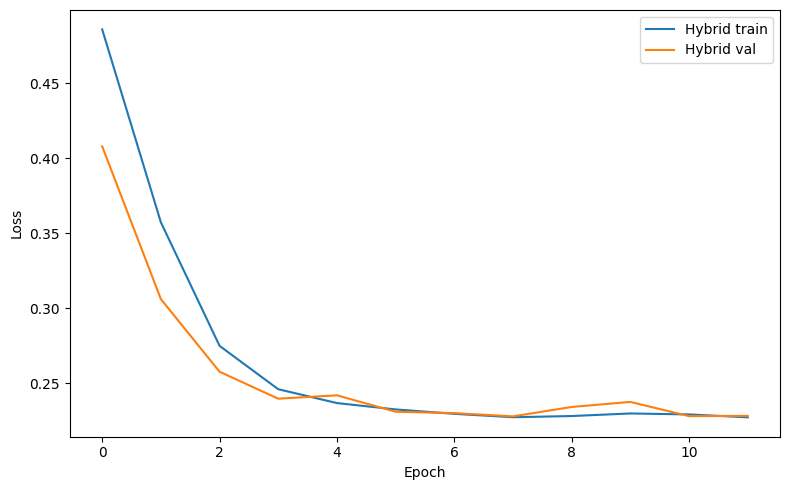

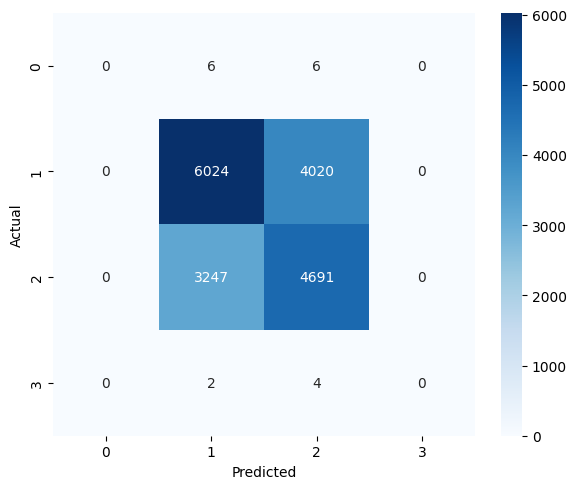

Training:   0%|          | 0/4 [00:00<?, ?epoch/s]

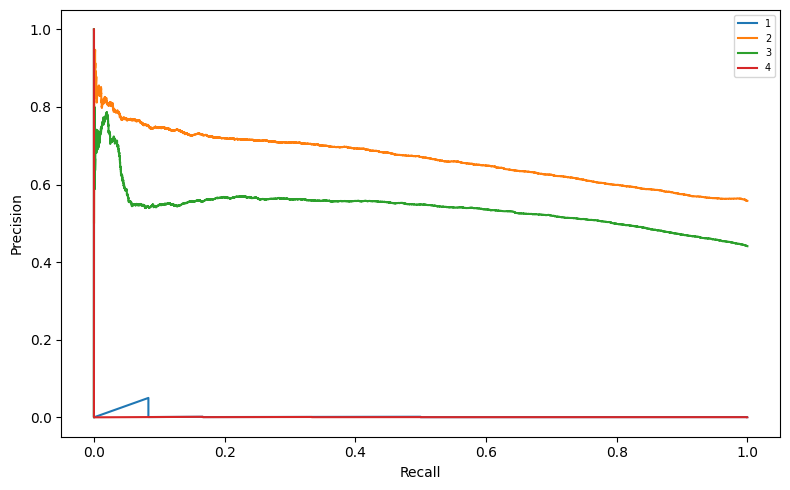

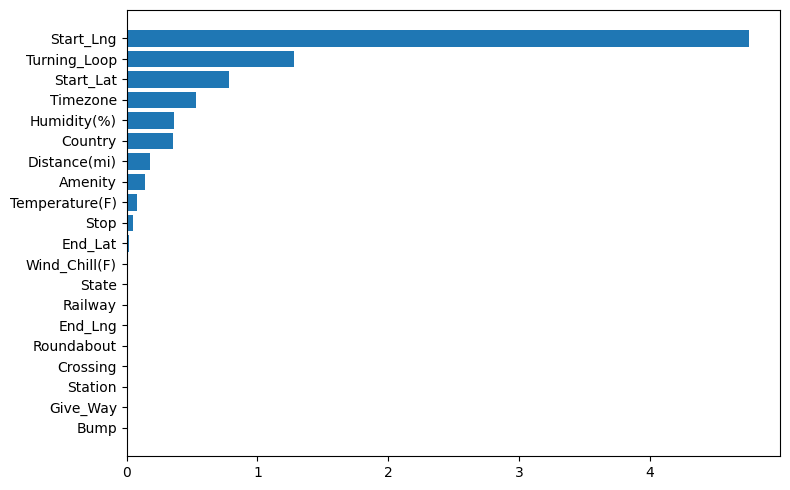

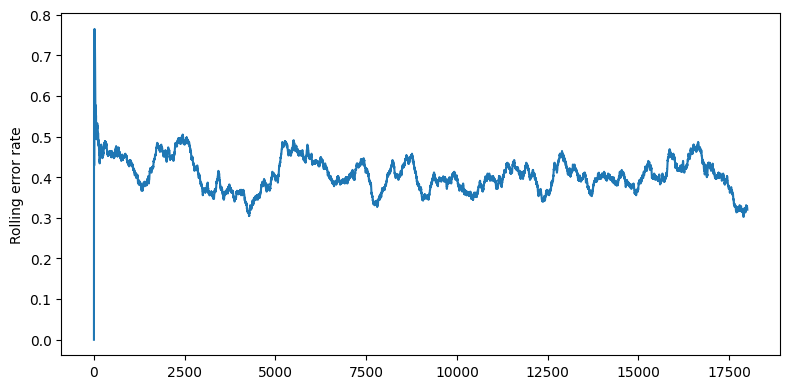

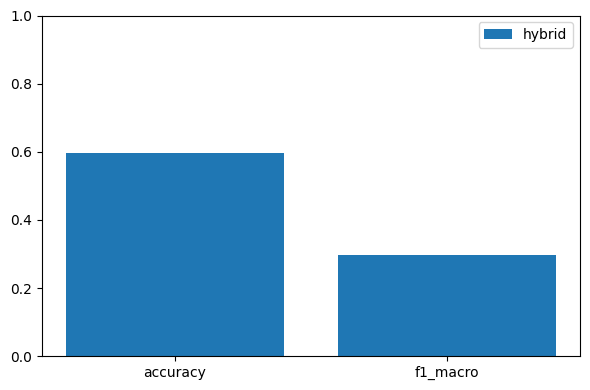

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(hybrid_history['train_loss'], label='Hybrid train')
plt.plot(hybrid_history['val_loss'], label='Hybrid val')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig01_loss_curves.png'), dpi=150)
plt.show()
cm = confusion_matrix(y_test, hybrid_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig02_confusion_matrix.png'), dpi=150)
plt.show()
plt.figure(figsize=(8, 5))
for k in tqdm(range(n_classes), desc='Training', unit='epoch'):
    binary = (y_test == k).astype(int)
    if binary.min() != binary.max():
        precision, recall, _ = precision_recall_curve(binary, hybrid_prob[:, k])
        plt.plot(recall, precision, label=str(label_encoder.classes_[k]))
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(fontsize=7)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig03_precision_recall.png'), dpi=150)
plt.show()
sample = next(iter(test_loader))
xb, coord, _ = sample
xb = xb[:min(64, len(xb))].to(DEVICE)
coord = coord[:len(xb)].to(DEVICE)
hybrid.zero_grad()
xb.requires_grad_(True)
scores = hybrid(xb, coord).sum()
scores.backward()
importance = (xb.grad * xb).abs().mean(0).detach().cpu().numpy()
top = np.argsort(importance)[-20:]
plt.figure(figsize=(8, 5))
plt.barh(np.array(feature_names)[top], importance[top])
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig04_feature_importance.png'), dpi=150)
plt.show()
errors = (hybrid_pred != y_test).astype(int)
plt.figure(figsize=(8, 4))
pd.Series(errors).rolling(max(5, len(errors) // 40), min_periods=1).mean().plot()
plt.ylabel('Rolling error rate')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig05_error_analysis.png'), dpi=150)
plt.show()
metric_names = ['accuracy', 'f1_macro']
x = np.arange(2)
plt.figure(figsize=(6, 4))
plt.bar(x, [results['hybrid'][m] for m in metric_names], label='hybrid')
plt.xticks(x, metric_names)
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['figures_dir'], 'fig06_proposed_metrics.png'), dpi=150)
plt.show()
